### Aviso e Bibliotecas
ATIVIDADE: SIMULADOR DE LANÇAMENTO DE UM PROJETIL

Instruções de Execução:
1. Certifique-se de ter o Python instalado.
2. Instale as dependências necessárias executando no terminal:
   - pip install numpy 
   - pip install matplotlib
   - pip install matplotlib numpy
   - pip install ipympl ipywidgets
   - pip install ipympl
3. Execute este script com o comando:
   teste_fisica.ipynb


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
import matplotlib.animation as animation
from matplotlib.animation import FuncAnimation

### Variavéis Iniciais

In [ ]:
v0_init = 50.0      # m/s (Escala sugerida: 5 a 150)
alpha_init = 45.0   # Graus (Escala sugerida: 1 a 89)
y0_init = 10.0      # m (Escala sugerida: 0 a 50)
g_init = 9.81       # m/s² (Escala sugerida: 1.6 a 24.8)
x0 = 0.0            # Posição x inicial fixa em zero

anim = None
historico_curvas = []  # Lista para armazenar as curvas salvas

### 01. Funções para cálcular o resultado e trajetória.

In [ ]:
def calcular_resultados(v0, alpha, y0, g):
    #Calcula os resultados numéricos pelas fórmulas analíticas fechadas (3), (4) e (5).
    theta = np.radians(alpha)
    
    # Equação (3): Tempo de voo
    termo_raiz = (v0 * np.sin(theta))**2 + 2 * g * y0
    tvoo = (v0 * np.sin(theta) + np.sqrt(termo_raiz)) / g
    
    # Equação (4): Altura máxima
    ymax = y0 + ((v0 * np.sin(theta))**2) / (2 * g)
    
    # Equação (5): Alcance horizontal total
    R = x0 + v0 * np.cos(theta) * tvoo
    
    return tvoo, ymax, R

In [ ]:
def calcular_trajetoria(v0, alpha, y0, g, tvoo):
    #Gera os vetores x e y usando as equações temporárias fechadas (1) e (2).
    theta = np.radians(alpha)
    t = np.linspace(0, tvoo, 200) # 200 pontos de tempo garantem uma curva suave
    
    # Equações (1) e (2)
    x = x0 + v0 * np.cos(theta) * t
    y = y0 + v0 * np.sin(theta) * t - 0.5 * g * t**2
    return t, x, y

### 02. Configuração do Ambiente Gráfico

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


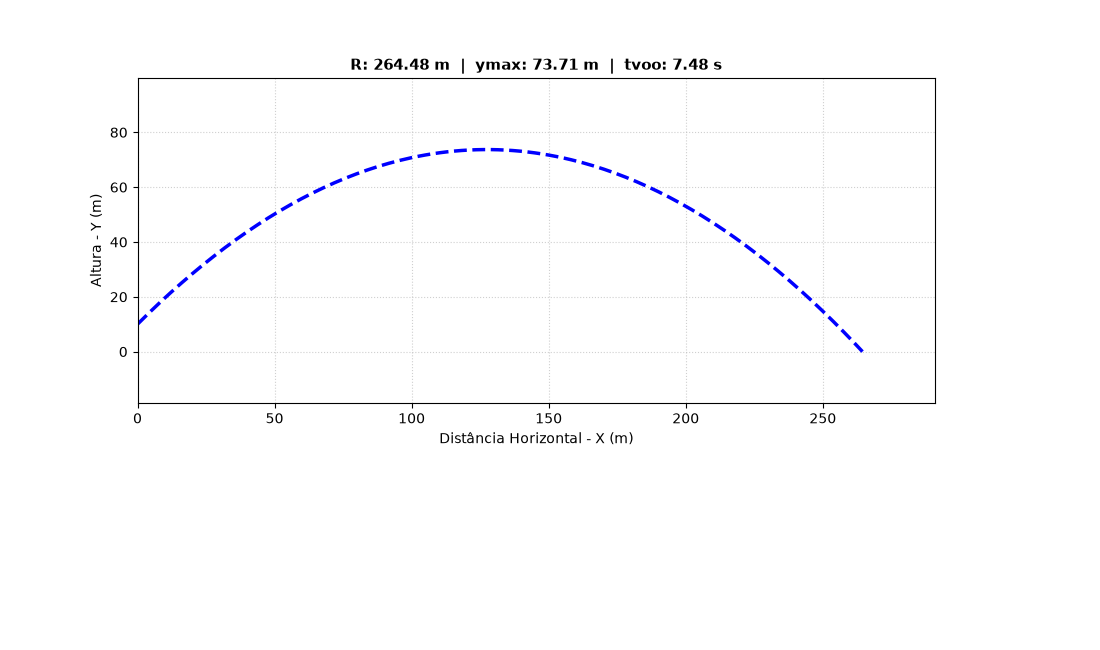

In [ ]:
fig, ax = plt.subplots(figsize=(11, 6.5))
plt.subplots_adjust(bottom=0.38, right=0.85) # Espaço reservado para os controles

# Estado inicial do sistema
tvoo, ymax, R = calcular_resultados(v0_init, alpha_init, y0_init, g_init)
_, x_init, y_init = calcular_trajetoria(v0_init, alpha_init, y0_init, g_init, tvoo)

# Elementos visuais primários (Linha de visualização dinâmica atual)
linha_atual, = ax.plot(x_init, y_init, lw=2.5, color='blue', linestyle='--', label='Configuração Atual')
ponto_projetil, = ax.plot([], [], 'ro', ms=8, zorder=5) # Projétil vermelho para animação

# Ajustes de eixos e rótulos obrigatórios (Requisito 5)
ax.set_xlabel("Distância Horizontal - X (m)", fontsize=10)
ax.set_ylabel("Altura - Y (m)", fontsize=10)
ax.grid(True, linestyle=':', alpha=0.6)
titulo = ax.set_title(f"R: {R:.2f} m  |  ymax: {ymax:.2f} m  |  tvoo: {tvoo:.2f} s", fontsize=11, weight='bold')

# Escala consistente 1:1 para evitar distorções espaciais (Requisito 5)
ax.set_xlim(0, max(10, R * 1.1))
ax.set_ylim(0, max(10, ymax * 1.1))
ax.set_aspect('equal', adjustable='datalim')

### 03. Interface Gráfica


In [ ]:
cor_bg = 'whitesmoke'
# Definição geométrica dos Sliders [esquerda, baixo, largura, altura]
ax_v0    = plt.axes([0.12, 0.26, 0.50, 0.03], facecolor=cor_bg)
ax_alpha = plt.axes([0.12, 0.20, 0.50, 0.03], facecolor=cor_bg)
ax_y0    = plt.axes([0.12, 0.14, 0.50, 0.03], facecolor=cor_bg)
ax_g     = plt.axes([0.12, 0.08, 0.50, 0.03], facecolor=cor_bg)

# Criação e tratamento de limites nativos para entradas inválidas (Requisito 6)
slider_v0    = Slider(ax_v0, '$v_0$ (m/s)', 5.0, 150.0, valinit=v0_init, valfmt='%1.1f')
slider_alpha = Slider(ax_alpha, r'$\theta$ (°)', 1.0, 89.0, valinit=alpha_init, valfmt='%1.1f')
slider_y0    = Slider(ax_y0, '$y_0$ (m)', 0.0, 50.0, valinit=y0_init, valfmt='%1.1f')
slider_g     = Slider(ax_g, '$g$ (m/s²)', 1.6, 24.8, valinit=g_init, valfmt='%1.1f')

# Botões de Ação (Lançar e Limpar Histórico)
ax_btn_lancar = plt.axes([0.70, 0.20, 0.12, 0.05])
btn_lancar = Button(ax_btn_lancar, 'Lançar', color='lightgreen', hovercolor='palegreen')

ax_btn_limpar = plt.axes([0.70, 0.12, 0.12, 0.05])
btn_limpar = Button(ax_btn_limpar, 'Limpar', color='tomato', hovercolor='salmon')

### 04. Funções de Interação

In [ ]:
def atualizar_grafico(val):
    
    global anim
    if anim:
        anim.event_source.stop() # Cancela animações ativas para não travar a UI
        
    v0, alpha, y0, g = slider_v0.val, slider_alpha.val, slider_y0.val, slider_g.val
    
    # Cálculos analíticos instantâneos
    novo_tvoo, nova_ymax, novo_R = calcular_resultados(v0, alpha, y0, g)
    _, novos_x, novos_y = calcular_trajetoria(v0, alpha, y0, g, novo_tvoo)
    
    # Atualização dos elementos gráficos existentes
    linha_atual.set_xdata(novos_x)
    linha_atual.set_ydata(novos_y)
    ponto_projetil.set_data([], [])
    titulo.set_text(f"R: {novo_R:.2f} m  |  ymax: {nova_ymax:.2f} m  |  tvoo: {novo_tvoo:.2f} s")
    
    # Ajuste dinâmico de enquadramento sem quebrar a proporção
    definir_limites_eixos(novo_R, nova_ymax)
    fig.canvas.draw_idle()

# Vincula a mudança dos sliders à função de atualização
slider_v0.on_changed(atualizar_grafico)
slider_alpha.on_changed(atualizar_grafico)
slider_y0.on_changed(atualizar_grafico)
slider_g.on_changed(atualizar_grafico)

0

### 05. Disparo de Projetil

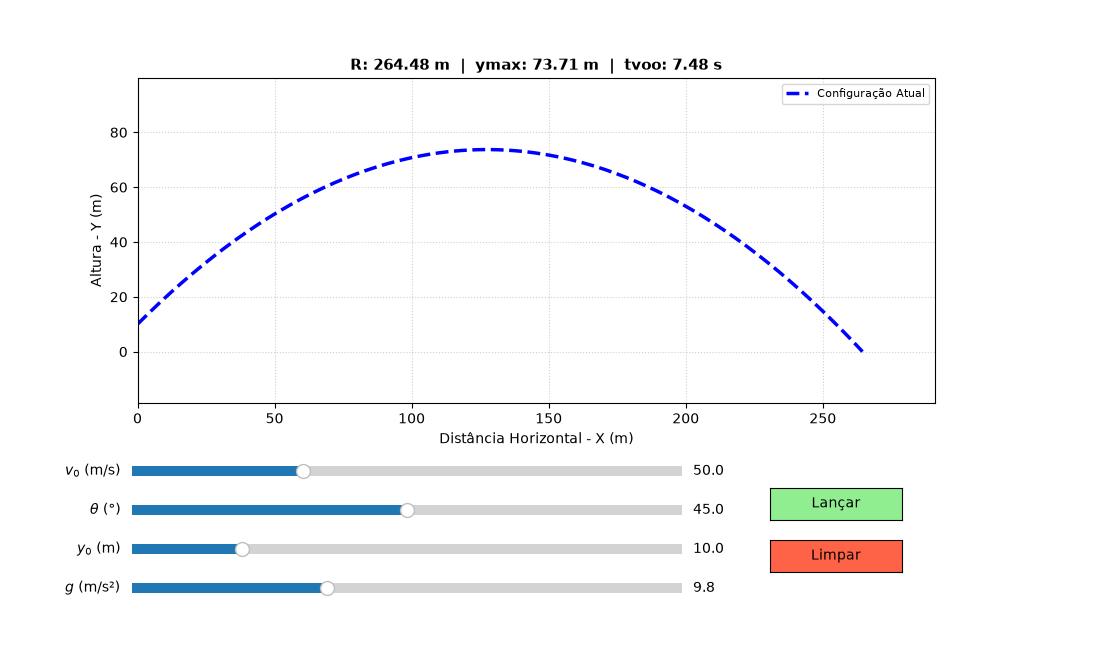

In [ ]:
def disparar_lancamento(event):
    global anim
    v0, alpha, y0, g = slider_v0.val, slider_alpha.val, slider_y0.val, slider_g.val
    tvoo_l, ymax_l, R_l = calcular_resultados(v0, alpha, y0, g)
    _, x_anim, y_anim = calcular_trajetoria(v0, alpha, y0, g, tvoo_l)
    
    label_historico = f"$v_0$={v0:.0f} | $\\theta$={alpha:.0f}° | $y_0$={y0:.0f}"
    linha_fixa, = ax.plot(x_anim, y_anim, lw=1.5, alpha=0.7, label=label_historico)
    historico_curvas.append(linha_fixa)
    ax.legend(loc='upper right', fontsize=8)
    
    # Reajusta os limites considerando as trajetórias antigas salvas
    definir_limites_eixos(R_l, ymax_l)

    # Função interna para atualizar a posição do frame da animação (Requisito 4)
    def animar(i):
        ponto_projetil.set_data([x_anim[i]], [y_anim[i]])
        return ponto_projetil,

    anim = animation.FuncAnimation(fig, animar, frames=len(x_anim), interval=12, blit=True, repeat=False)
    fig.canvas.draw_idle()

def limpar_historico(event):
    #Remove todas as trajetórias salvas e limpa a área de plotagem.
    global historico_curvas
    for linha in historico_curvas:
        linha.remove()
    historico_curvas.clear()
    ax.legend(loc='upper right', fontsize=8)
    atualizar_grafico(None)

def definir_limites_eixos(r_atual, y_atual):
    #Garante que todas as curvas caibam na tela sem distorção métrica.
    max_x = max([line.get_xdata()[-1] for line in historico_curvas] + [r_atual, 10])
    max_y = max([max(line.get_ydata()) for line in historico_curvas] + [y_atual, 10])
    ax.set_xlim(0, max_x * 1.1)
    ax.set_ylim(0, max_y * 1.1)
    ax.set_aspect('equal', adjustable='datalim')

# Vincula as ações dos botões
btn_lancar.on_clicked(disparar_lancamento)
btn_limpar.on_clicked(limpar_historico)

ax.legend(loc='upper right', fontsize=8)
plt.show()